<a href="https://colab.research.google.com/github/Bavathayini-N/Sports_Football_EDA/blob/main/Sports_Footwear_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EXPLORATORY DATA ANALYSIS

In [12]:
pip install pandas numpy matplotlib seaborn scipy scikit-learn statsmodels missingno


In [13]:
import pandas as pd

path = "13_Sport Footwear Prediction and Analysis.csv"
df = pd.read_csv(path, parse_dates=["order_date"], dayfirst=False, low_memory=False)



In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
df.shape

(30000, 18)

In [16]:
df.head()

,order_id,order_date,brand,model_name,category,gender,size,color,base_price_usd,discount_percent,final_price_usd,units_sold,revenue_usd,payment_method,sales_channel,country,customer_income_level,customer_rating
0,ORD100000,2021-01-30,ASICS,Model-370,Running,Unisex,8,Black,162,15,137.70,1,137.7,Card,Retail Store,Germany,Low,4.6
1,ORD100001,2026-10-05,Reebok,Model-314,Lifestyle,Men,8,Grey,80,5,76.00,3,228.0,Card,Online,USA,Low,3.9
2,ORD100002,2023-11-12,ASICS,Model-763,Lifestyle,Men,8,Black,176,15,149.60,4,598.4,Cash,Retail Store,India,Medium,3.0
3,ORD100003,2026-08-29,Reebok,Model-905,Basketball,Women,7,White,61,15,51.85,2,103.7,Card,Retail Store,India,High,3.4
4,ORD100004,2019-11-09,Nike,Model-413,Training,Men,11,Black,80,0,80.00,4,320.0,Cash,Online,USA,Medium,3.0


In [17]:
df.dtypes

,0
order_id,object
order_date,datetime64[ns]
brand,object
model_name,object
category,object
gender,object
size,int64
color,object
base_price_usd,int64
discount_percent,int64


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   order_id               30000 non-null  object        
 1   order_date             30000 non-null  datetime64[ns]
 2   brand                  30000 non-null  object        
 3   model_name             30000 non-null  object        
 4   category               30000 non-null  object        
 5   gender                 30000 non-null  object        
 6   size                   30000 non-null  int64         
 7   color                  30000 non-null  object        
 8   base_price_usd         30000 non-null  int64         
 9   discount_percent       30000 non-null  int64         
 10  final_price_usd        30000 non-null  float64       
 11  units_sold             30000 non-null  int64         
 12  revenue_usd            30000 non-null  float64       
 13  p

In [19]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
order_id,30000,30000,ORD129983,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_date,30000,NaN,NaN,NaN,2022-06-28 06:41:02.400000256,2018-01-01 00:00:00,2020-04-02 00:00:00,2022-06-25 00:00:00,2024-09-30 00:00:00,2026-12-31 00:00:00,NaN
brand,30000,6,ASICS,5132,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_name,30000,899,Model-863,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,30000,5,Basketball,6074,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,30000,3,Men,10075,NaN,NaN,NaN,NaN,NaN,NaN,NaN
size,30000.0,NaN,NaN,NaN,8.500867,6.0,7.0,9.0,10.0,11.0,1.710896
color,30000,5,Grey,6046,NaN,NaN,NaN,NaN,NaN,NaN,NaN
base_price_usd,30000.0,NaN,NaN,NaN,139.634633,60.0,100.0,140.0,180.0,219.0,46.062549
discount_percent,30000.0,NaN,NaN,NaN,13.332167,0.0,5.0,10.0,20.0,30.0,9.864198


In [20]:
# missing values overview
df.isna().sum()

,0
order_id,0
order_date,0
brand,0
model_name,0
category,0
gender,0
size,0
color,0
base_price_usd,0
discount_percent,0


In [21]:
exact_dup_mask = df.duplicated(keep=False)   # True for all duplicate occurrences
exact_dup_count = exact_dup_mask.sum()
exact_dup_count


np.int64(0)

# CHECKING OUTLIERS

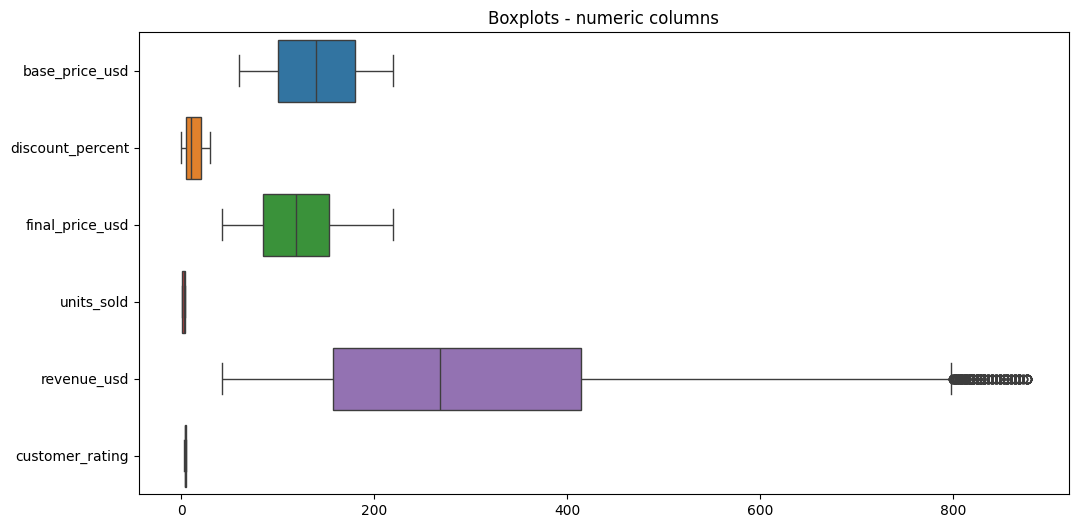

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ["base_price_usd","discount_percent","final_price_usd","units_sold","revenue_usd","customer_rating"]
plt.figure(figsize=(12,6))
sns.boxplot(data=df[num_cols], orient="h")
plt.title("Boxplots - numeric columns")
plt.show()


In [23]:

def iqr_bounds(s, k=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - k*iqr, q3 + k*iqr

low, high = iqr_bounds(df['revenue_usd'].dropna(), k=1.5)
outlier_mask = (df['revenue_usd'] < low) | (df['revenue_usd'] > high)
df_outliers = df[outlier_mask]
df_outliers.shape, (low, high)


((231, 18), (np.float64(-229.125), np.float64(799.875)))

# FEATURE ENGINEERING

In [24]:
import pandas as pd
import numpy as np

df = pd.read_csv("13_Sport Footwear Prediction and Analysis.csv", parse_dates=["order_date"], low_memory=False)
df_orig = df.copy()

# Basic features
df['sku'] = df['brand'].astype(str) + '|' + df['model_name'].astype(str)
df['unit_price'] = np.where(df['units_sold']>0, df['final_price_usd'] / df['units_sold'], df['final_price_usd'])
df['computed_discount'] = ((df['base_price_usd'] - df['final_price_usd']) / df['base_price_usd']).replace([np.inf,-np.inf], np.nan).fillna(0)
df['discount_flag'] = (df['computed_discount'] > 0).astype(int)

# Targets / transforms
df['log_revenue'] = np.log1p(df['revenue_usd'].clip(lower=0))
df['log_units'] = np.log1p(df['units_sold'].clip(lower=0))
df['is_bulk'] = (df['units_sold'] >= 5).astype(int)

# Customer
income_map = {'Low':0, 'Medium':1, 'High':2}
df['income_level_enc'] = df['customer_income_level'].map(income_map).fillna(-1).astype(int)
df['rating_bucket'] = pd.cut(df['customer_rating'].fillna(df['customer_rating'].median()), bins=[0,3,4.5,5], labels=['low','medium','high'])
df['orders_by_country'] = df.groupby('country')['order_id'].transform('nunique')

# Brand aggregates
brand_stats = df.groupby('brand').agg(brand_total_revenue=('revenue_usd','sum'),brand_total_units=('units_sold','sum'),brand_avg_price=('unit_price','mean')
).reset_index()
brand_stats['brand_rank'] = brand_stats['brand_total_revenue'].rank(ascending=False, method='dense').astype(int)
df = df.merge(brand_stats, on='brand', how='left')

# UNIVARIATE ANALYSIS

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['unit_price','computed_discount','units_sold','revenue_usd','customer_rating','log_revenue','log_units']

# Summary stats
df[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
unit_price,30000.0,63.106831,43.448112,10.500000,32.175000,48.500000,80.750000,219.000000
computed_discount,30000.0,0.133322,0.098642,0.000000,0.050000,0.100000,0.200000,0.300000
units_sold,30000.0,2.500200,1.121149,1.000000,1.000000,3.000000,4.000000,4.000000
revenue_usd,30000.0,302.714948,179.149272,42.000000,156.750000,268.200000,414.000000,876.000000
customer_rating,30000.0,4.001543,0.577546,3.000000,3.500000,4.000000,4.500000,5.000000
log_revenue,30000.0,5.527222,0.642180,3.761200,5.061012,5.595455,6.028279,6.776507
log_units,30000.0,1.196607,0.343596,0.693147,0.693147,1.386294,1.609438,1.609438


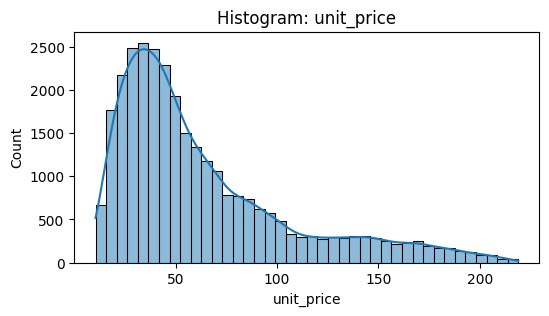

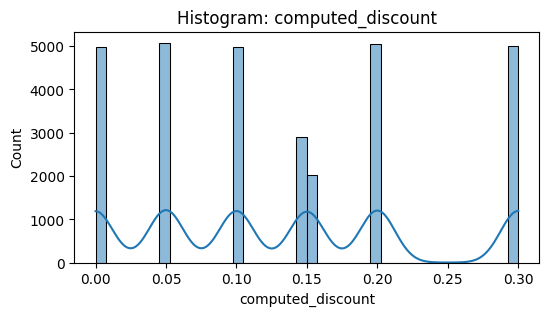

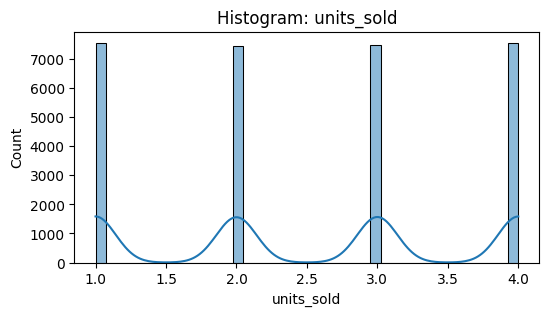

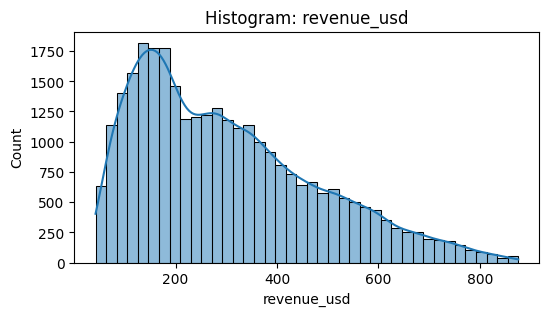

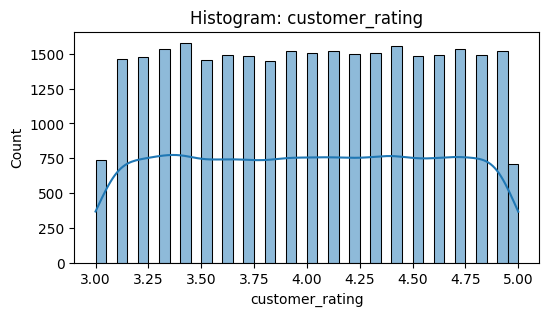

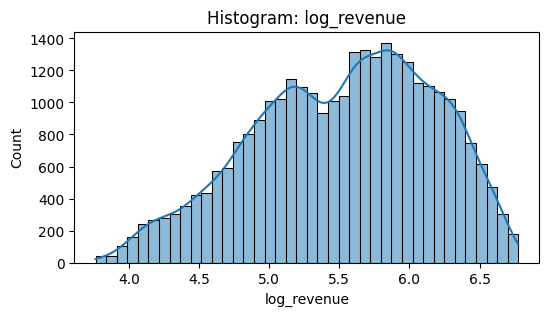

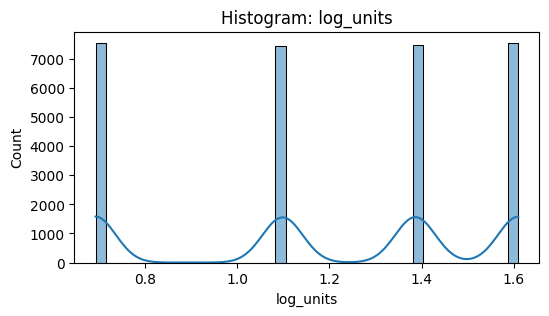

In [26]:
# Histograms
for c in num_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[c].dropna(), bins=40, kde=True)
    plt.title(f'Histogram: {c}')
    plt.show()


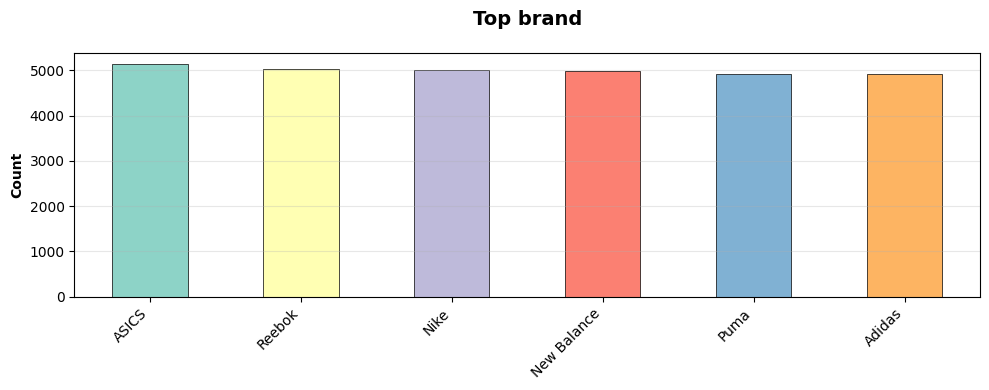

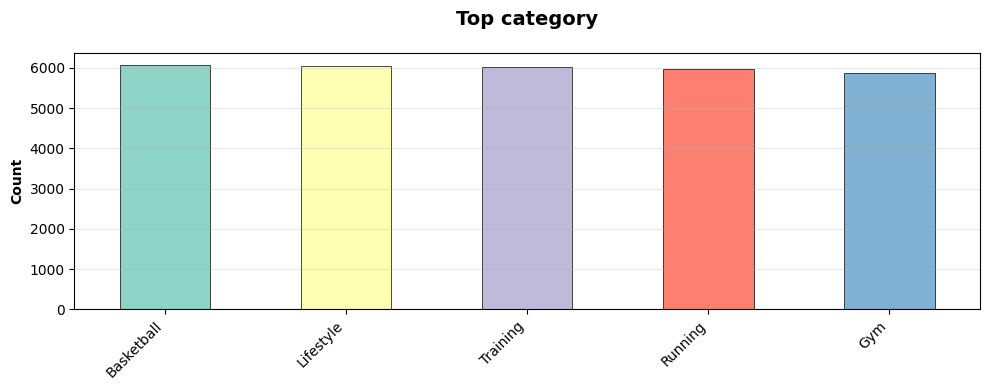

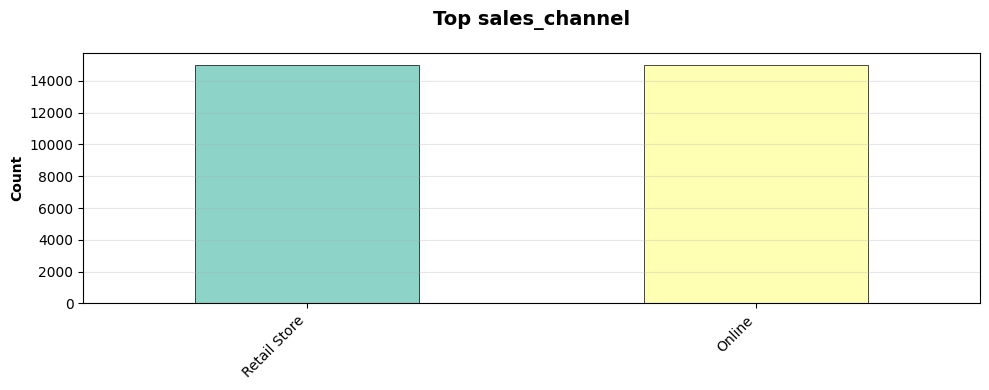

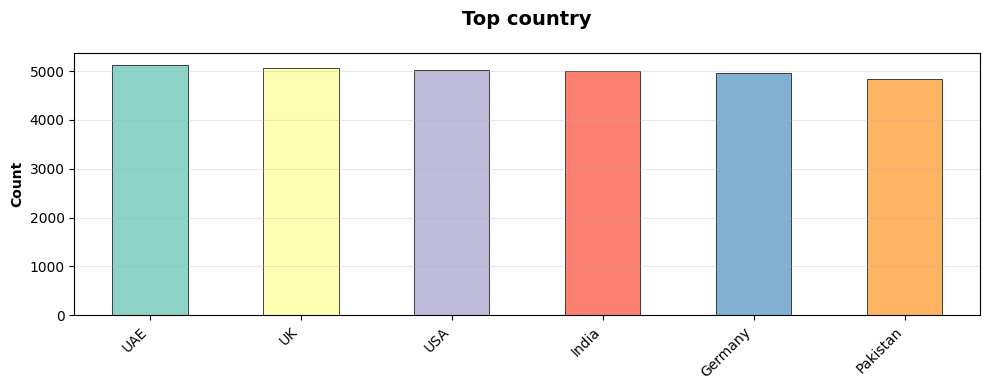

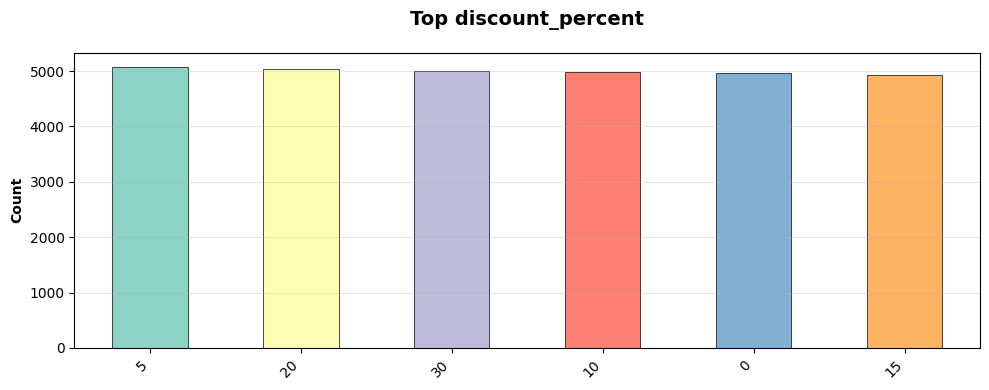

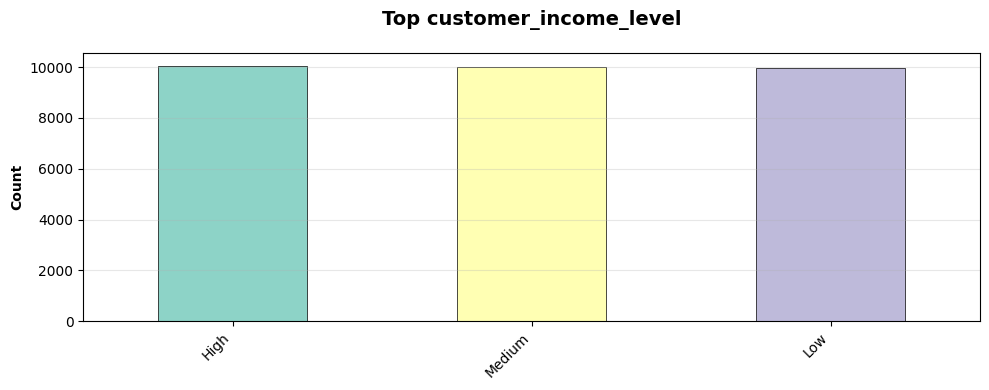

In [27]:
cat_cols = ['brand','category','sales_channel','country','discount_percent','customer_income_level']

for c in cat_cols:
    top20 = df[c].value_counts().head(20)

    plt.figure(figsize=(10,4))
    colors = plt.cm.Set3(range(len(top20)))
    top20.plot(kind='bar', color=colors, edgecolor='black', linewidth=0.5)

    plt.title(f'Top {c}', fontweight='bold', fontsize=14, pad=20)
    plt.ylabel('Count', fontweight='bold')
    plt.xlabel('')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Bivariate Analysis

In [28]:
cat_feats = ['brand','category','gender','sales_channel','country','rating_bucket','discount_flag']

# Group mean/median/count for units and revenue
for c in cat_feats:
    agg = df.groupby(c)[['units_sold','revenue_usd']].agg(['mean','median','count']).sort_values(('units_sold','count'), ascending=False).head(2)
    print(f"\n------------------------------------ {c} ------------------------------------ \n\n", agg)




------------------------------------ brand ------------------------------------ 

        units_sold              revenue_usd               
             mean median count        mean   median count
brand                                                    
ASICS    2.508574    2.0  5132  304.260035  267.575  5132
Reebok   2.480899    2.0  5026  298.177656  258.800  5026

------------------------------------ category ------------------------------------ 

            units_sold              revenue_usd             
                 mean median count        mean median count
category                                                   
Basketball   2.495884    2.0  6074  300.027931  264.0  6074
Lifestyle    2.496947    3.0  6059  304.444422  270.3  6059

------------------------------------ gender ------------------------------------ 

        units_sold               revenue_usd              
             mean median  count        mean median  count
gender                                

/tmp/ipykernel_1115/2328469146.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby(c)[['units_sold','revenue_usd']].agg(['mean','median','count']).sort_values(('units_sold','count'), ascending=False).head(2)


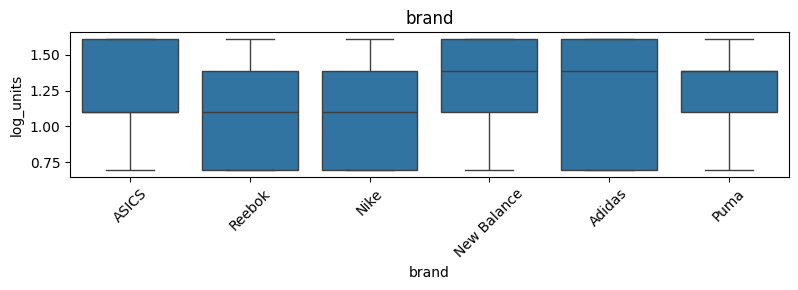

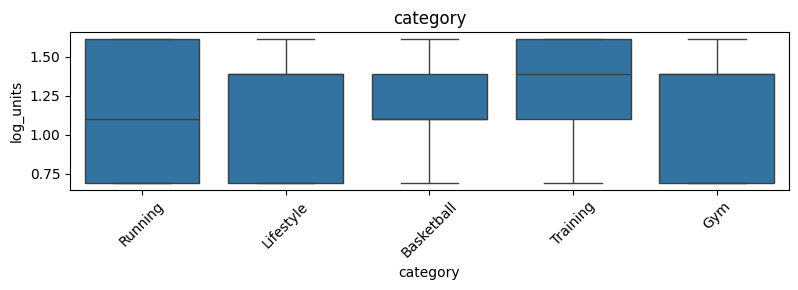

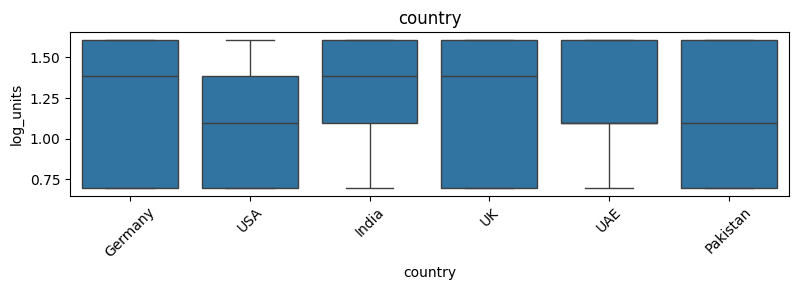

In [29]:
# Example boxplot for top levels of a categorical feature
for c in ['brand','category','country']:
    top = df[c].value_counts().nlargest(8).index
    plt.figure(figsize=(8,3))
    sns.boxplot(data=df[df[c].isin(top)], x=c, y='log_units')
    plt.xticks(rotation=45)
    plt.title(c)
    plt.tight_layout()
    plt.show()


# Correlation Matrix

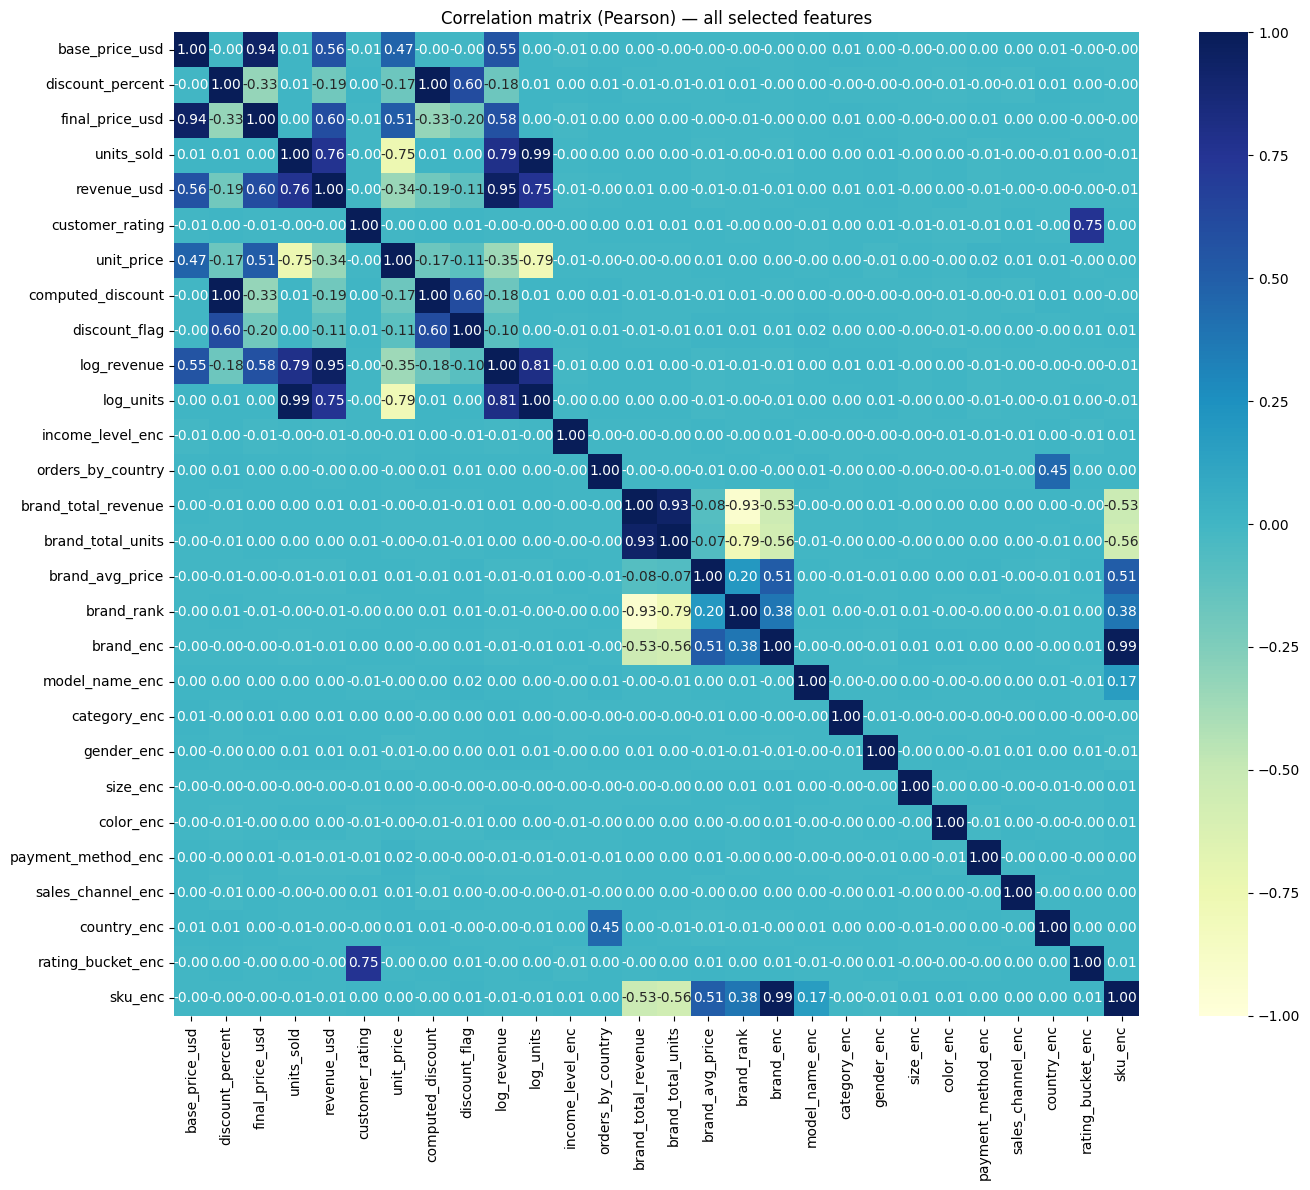


Top correlations with revenue:
revenue_usd           1.000000
log_revenue           0.945737
units_sold            0.759549
log_units             0.752403
final_price_usd       0.595679
base_price_usd        0.562852
unit_price            0.340233
computed_discount     0.187818
discount_percent      0.187818
discount_flag         0.109604
gender_enc            0.014471
brand_avg_price       0.008578
income_level_enc      0.008565
payment_method_enc    0.008123
category_enc          0.007777
Name: revenue_usd, dtype: float64


In [30]:

cat_cols = ['brand','model_name','category','gender','size','color','payment_method','sales_channel','country','rating_bucket','order_month','sku']
for c in cat_cols:
    if c in df.columns:
        df[c + '_enc'] = df[c].astype('category').cat.codes

# Select columns for correlation (numeric + engineered)
cols_for_corr = [
    # original numeric
    'base_price_usd','discount_percent','final_price_usd','units_sold','revenue_usd','customer_rating',
    # engineered numeric
    'unit_price','computed_discount','discount_flag','log_revenue','log_units',
    'income_level_enc','orders_by_country',
    # aggregated
    'brand_total_revenue','brand_total_units','brand_avg_price','brand_rank'
]
# add encoded categorical columns
cols_for_corr += [c + '_enc' for c in cat_cols if c in df.columns]

# keep only columns that exist
cols_for_corr = [c for c in cols_for_corr if c in df.columns]

# compute correlation matrix (Pearson)
corr = df[cols_for_corr].corr()

# Plot heatmap
plt.figure(figsize=(14,12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='YlGnBu', center=0, vmax=1, vmin=-1, square=False)
plt.title('Correlation matrix (Pearson) — all selected features')
plt.tight_layout()
plt.show()

# summary: top correlations with revenue_usd and units_sold
target = 'revenue_usd' if 'revenue_usd' in df.columns else 'log_revenue'
print("\nTop correlations with revenue:")
print(corr[target].abs().sort_values(ascending=False).head(15))



# HYPOTHESIS

In [31]:
# Total revenue by brand
brand_revenue = df.groupby('brand', dropna=False)['revenue_usd'].sum().reset_index().sort_values('revenue_usd', ascending=False)
print(brand_revenue.head(50))

         brand  revenue_usd
0        ASICS   1561462.50
3         Nike   1524582.10
2  New Balance   1511401.50
4         Puma   1499094.90
5       Reebok   1498640.90
1       Adidas   1486266.55


In [32]:
top3 = df.groupby('brand', dropna=False)['revenue_usd'].sum().nlargest(3).index.tolist()
top3


['ASICS', 'Nike', 'New Balance']

# HYP 1: units_sold -> revenue_usd

In [33]:
#H0: There is no linear correlation between units_sold and revenue_usd (ρ = 0)
#H1: There is a positive linear correlation between units_sold and revenue_usd (ρ > 0)

from scipy.stats import pearsonr

corr_units, p_units = pearsonr(df['units_sold'].dropna(), df['revenue_usd'].dropna())
print("TEST 1 RESULTS:")
print(f"Correlation coefficient: {corr_units:.4f}")
print(f"P-value: {p_units:.4f}")
print(f"{'REJECT H0' if p_units < 0.05 else ' ACCEPT H0'} ")


TEST 1 RESULTS:
Correlation coefficient: 0.7595
P-value: 0.0000
REJECT H0 


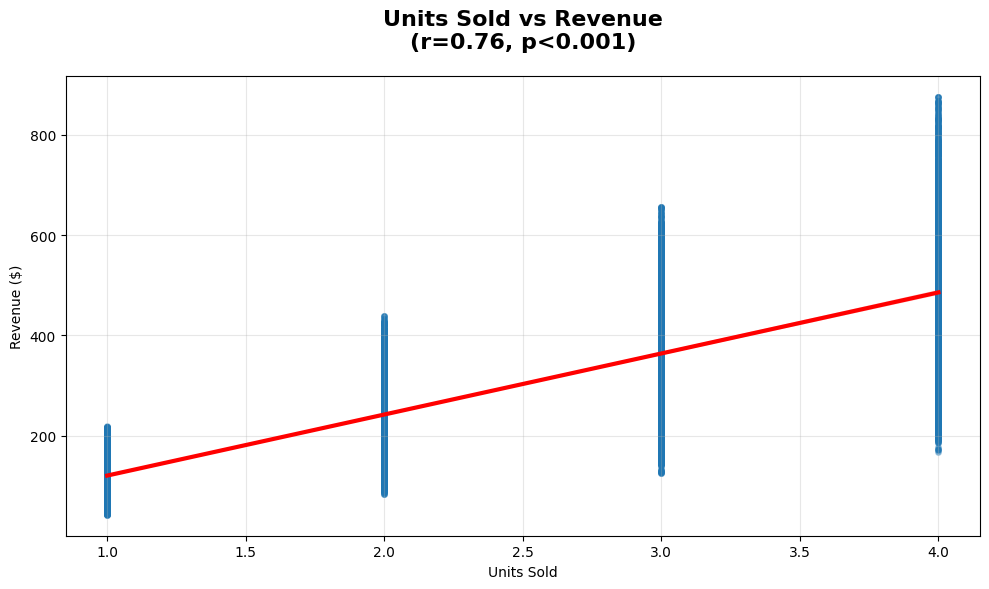

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))

# Scatter with regression line
sns.regplot(data=df.sample(10000), x='units_sold', y='revenue_usd',
            scatter_kws={'alpha':0.4, 's':15},
            line_kws={'color':'red', 'lw':3})

plt.title('Units Sold vs Revenue\n(r=0.76, p<0.001)',
          fontweight='bold', fontsize=16, pad=20)
plt.xlabel('Units Sold', fontsize=10)
plt.ylabel('Revenue ($)', fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# HYP 2: Country_enc -> revenue

In [35]:
#H0: Mean revenue_usd is equal across all country_enc groups (μ₁ = μ₂ = ... = μₙ)
#H1: Mean revenue_usd differs across country_enc groups (at least one μᵢ ≠ μⱼ)

from scipy.stats import f_oneway

# Test 2: ANOVA country_enc vs revenue
country_groups = [group['revenue_usd'].dropna() for name, group in df.groupby('country_enc')]
f_stat_country, p_country = f_oneway(*country_groups)
print("TEST 2 RESULTS (ANOVA):")
print(f"F-statistic: {f_stat_country:.4f}")
print(f"P-value: {p_country:.4f}")
print(f"{'REJECT H0' if p_country < 0.05 else 'ACCEPT H0'} - {'COUNTRY EFFECTS SIGNIFICANT' if p_country < 0.05 else 'NO COUNTRY EFFECT'}")


TEST 2 RESULTS (ANOVA):
F-statistic: 0.2633
P-value: 0.9332
ACCEPT H0 - NO COUNTRY EFFECT


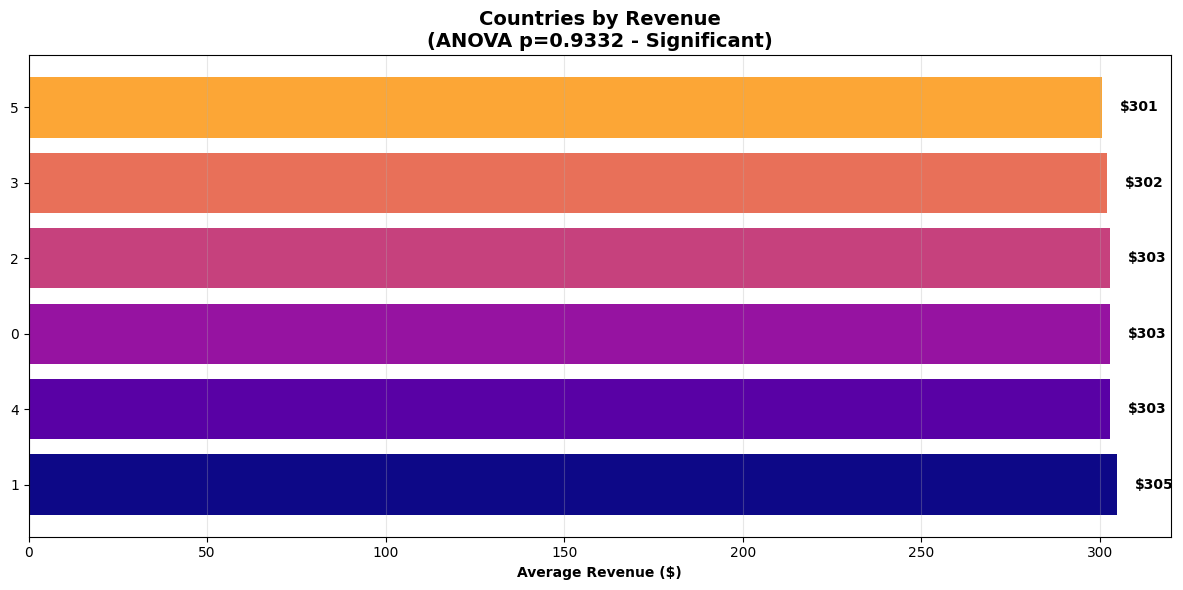

In [36]:

country_means = df.groupby('country_enc')['revenue_usd'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
colors = plt.cm.plasma(np.linspace(0, 0.8, len(country_means)))
bars = plt.barh(range(len(country_means)), country_means.values, color=colors)
plt.yticks(range(len(country_means)), country_means.index)
plt.xlabel('Average Revenue ($)', fontweight='bold')
plt.title('Countries by Revenue\n(ANOVA p=%.4f - Significant)' % p_country,
          fontweight='bold', fontsize=14)

# Add values + stats
for i, v in enumerate(country_means.values):
    plt.text(v + 5, i, f'${v:.0f}', va='center', fontweight='bold')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# HYP 3: discount_percent -> revenue_usd

In [37]:
#H0: There is no linear correlation between discount_percent and revenue_usd (ρ = 0)
#H1: There is a linear correlation between discount_percent and revenue_usd (ρ ≠ 0)# Test 6: discount_percent vs revenue

corr_disc_pct, p_disc_pct = pearsonr(df['discount_percent'].dropna(), df['revenue_usd'].dropna())
print("TEST 3 RESULTS:")
print(f"Correlation coefficient: {corr_disc_pct:.4f}")
print(f"P-value: {p_disc_pct:.4f}")
print(f"{'REJECT H0' if p_disc_pct < 0.05 else 'ACCEPT  H0'}")

TEST 3 RESULTS:
Correlation coefficient: -0.1878
P-value: 0.0000
REJECT H0


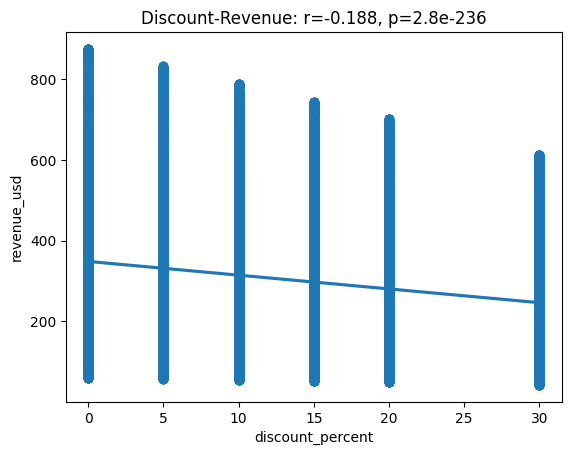

In [38]:
corr, p = pearsonr(df['discount_percent'].dropna(), df['revenue_usd'].dropna())
sns.regplot(data=df, x='discount_percent', y='revenue_usd')
plt.title(f'Discount-Revenue: r={corr:.3f}, p={p:.1e}'); plt.show()

# HYP 4 : discount_flag vs revenue

In [45]:
#H0: Mean revenue_usd is equal between discount_flag groups
#H1: Mean revenue_usd differs between discount_flag groups
from scipy.stats import ttest_ind

disc_rev = df[df['discount_flag'] == 1]['revenue_usd'].dropna()
no_disc_rev = df[df['discount_flag'] == 0]['revenue_usd'].dropna()
t_disc_flag, p_disc_flag = ttest_ind(disc_rev, no_disc_rev, equal_var=False)

print("TEST  RESULTS (t-test):")
print(f"Discounted mean revenue: ${disc_rev.mean():.2f} (n={len(disc_rev)})")
print(f"No-discount mean revenue: ${no_disc_rev.mean():.2f} (n={len(no_disc_rev)})")
print(f"t-statistic: {t_disc_flag:.4f}")
print(f"P-value: {p_disc_flag:.4f}")
print(f"{'REJECT H0' if p_disc_flag < 0.05 else 'ACCEPT H0'}")


TEST  RESULTS (t-test):
Discounted mean revenue: $293.96 (n=25029)
No-discount mean revenue: $346.77 (n=4971)
t-statistic: -17.3449
P-value: 0.0000
REJECT H0


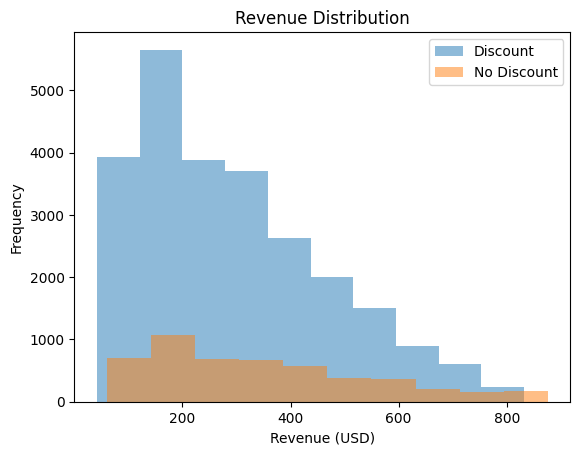

In [44]:
plt.figure()

plt.hist(disc_rev, alpha=0.5, label='Discount')
plt.hist(no_disc_rev, alpha=0.5, label='No Discount')

plt.xlabel("Revenue (USD)")
plt.ylabel("Frequency")
plt.title("Revenue Distribution")
plt.legend()

plt.show()

# HYP 5: UNIT PRICE -> REVENUE

In [42]:
#H0: Unit price doesn't affect revenue
#H1: Higher unit price leads to Higher revenue

# Create price bins (Low/Med/High)
df['price_bin'] = pd.qcut(df['unit_price'], q=3, labels=['Low', 'Med', 'High'])

# ANOVA test
price_groups = [group['revenue_usd'].dropna() for name, group in df.groupby('price_bin')]
f_stat, p_anova = f_oneway(*price_groups)

print("PRICE BINS REVENUE:")
print(df.groupby('price_bin')['revenue_usd'].agg(['mean', 'count']).round(0))
print(f"\nANOVA: F={f_stat:.2f}, p={p_anova:.4f}")
print(f"{'REJECT H0' if p_anova<0.05 else 'ACCEPT H0'}")


PRICE BINS REVENUE:
            mean  count
price_bin              
Low        313.0  10006
Med        394.0  10008
High       201.0   9986

ANOVA: F=3660.88, p=0.0000
REJECT H0


/tmp/ipykernel_1115/2869448536.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_groups = [group['revenue_usd'].dropna() for name, group in df.groupby('price_bin')]
/tmp/ipykernel_1115/2869448536.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('price_bin')['revenue_usd'].agg(['mean', 'count']).round(0))


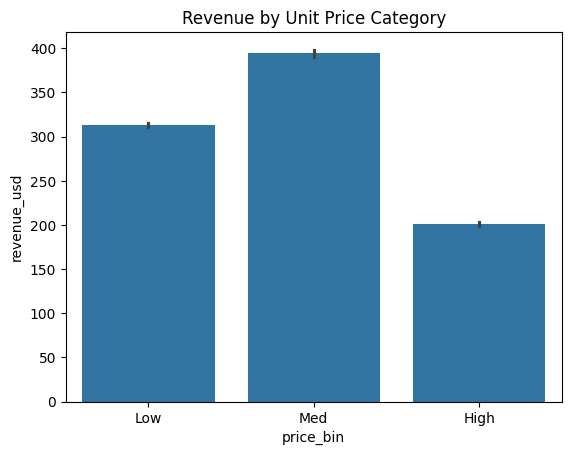

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()

sns.barplot(x='price_bin', y='revenue_usd', data=df)

plt.title("Revenue by Unit Price Category")

plt.show()

# HYP 6: category -> revenue_usd

In [43]:
#H0: Mean revenue_usd is equal across all category groups
#H1: Mean revenue_usd differs across category groups

category_groups = [group['revenue_usd'].dropna() for name, group in df.groupby('category')]
f_category, p_category = f_oneway(*category_groups)
print("TEST 4 RESULTS (ANOVA):")
print(f"F-statistic: {f_category:.4f}")
print(f"P-value: {p_category:.4f}")
print(f"{'REJECT H0' if p_category < 0.05 else 'ACCEPT H0'} - {'CATEGORY EFFECTS SIGNIFICANT' if p_category < 0.05 else 'NO CATEGORY EFFECT'}")


TEST 4 RESULTS (ANOVA):
F-statistic: 0.8133
P-value: 0.5164
ACCEPT H0 - NO CATEGORY EFFECT


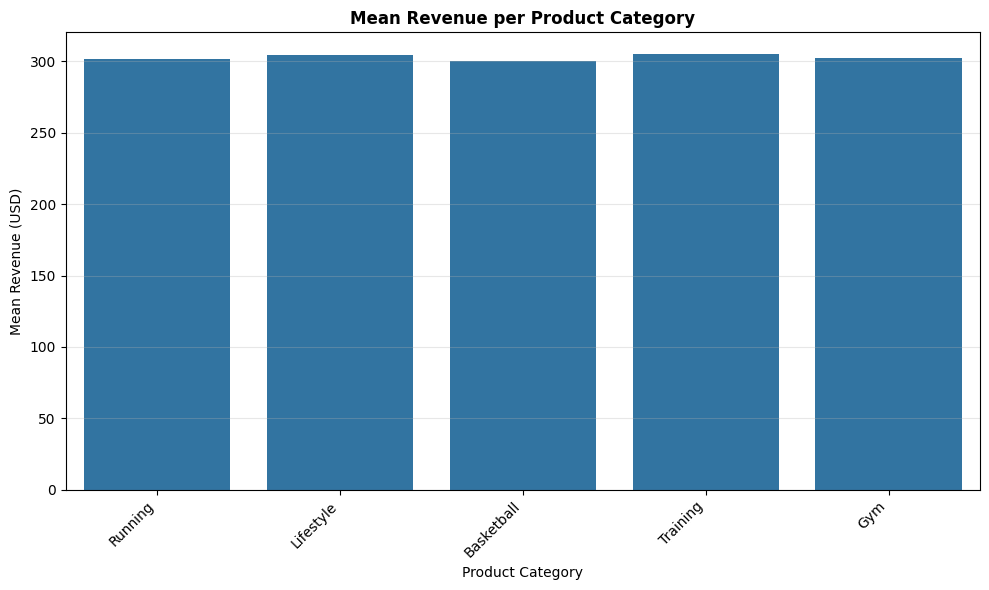

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(x='category', y='revenue_usd', data=df, errorbar=None)
plt.title('Mean Revenue per Product Category', fontweight='bold')
plt.xlabel('Product Category')
plt.ylabel('Mean Revenue (USD)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()